In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
#load data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')


In [3]:
#look at data
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
train.dtypes
#change Heart Disease into 0's and 1's. 0's means its absent, 1 its present
train['Heart Disease'] = train['Heart Disease'].map({
    "Absence": 0,
    "Presence": 1
})

In [5]:
train.columns

#lets look at how balanced the data is
#print("this is how balanced it is" + str(sum(train['Heart Disease']) / len(train['Heart Disease'])))

#0.44 percent is not that bad


Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [6]:
#explore thallium to see if we could simplify it for our model
train['Thallium'].unique()
#considering some googling we will add new categories based on these ints
train['normal_heart'] = (train['Thallium'] == 3).astype(int)
train['fixed_heart_defect'] = (train['Thallium'] == 6).astype(int)
train['reversible_heart_defect'] = (train['Thallium'] == 7).astype(int)

#lets try to bin some age categories
train.head()
#classify chest pains
train['Chest pain type'].unique()

#chest pain of 4 means a no pain, and chest pain of 1 means a lot of pain
train['cp_none'] = (train['Chest pain type'] == 4).astype(int)
train['cp_low'] = (train['Chest pain type'] == 3).astype(int)
train['cp_medium'] = (train['Chest pain type'] == 2).astype(int)
train['cp_high'] = (train['Chest pain type'] == 1).astype(int)


#exercise and stress interaction
train["stress_ST_interaction"] = (
    train["Exercise angina"] * train["ST depression"]
)

#cholestrol risk buckets
train["cholesterol_high"] = (train["Cholesterol"] > 240).astype(int)
train["cholesterol_very_high"] = (train["Cholesterol"] > 300).astype(int)

#st depression 
train["st_depression_high"] = (train["ST depression"] >= 2).astype(int)
#low bpm
train["low_max_hr"] = (train["Max HR"] < 120).astype(int)
#blood pressure risk
train["bp_high"] = (train["BP"] >= 140).astype(int)
#heart defect
train["multi_vessel_disease"] = (train["Number of vessels fluro"] >= 2).astype(int)

train["major_risk_combo"] = (
    (train["ST depression"] > 2) &
    (train["Exercise angina"] == 1) &
    (train["Number of vessels fluro"] >= 1)
).astype(int)

bins = [0, 50, 55, 60, 65, 120]

labels = [
    "Low",
    "Medium",
    "High",
    "Medium",
    "Low"
]

train["age_risk_bin"] = pd.cut(
    train["Age"],
    bins=bins,
    labels=labels,
    right=False,
    ordered=False
)

train["st_squared"] = train["ST depression"] ** 2
train["severe_vessel"] = (train["Number of vessels fluro"] >= 3).astype(int)
train["hr_stress_ratio"] = train["Max HR"] / (train["Age"] + 1)

from scipy.stats.mstats import winsorize

#lets get outliers and apply winsorization
# num_cols = [
#     'Cholesterol',
#        'FBS over 120', 'EKG results', 'Max HR', 
#        'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
#        'Heart Disease', 'normal_heart', 'fixed_heart_defect',
#        'reversible_heart_defect', 'cp_none', 'cp_low', 'cp_medium', 'cp_high',
#        'stress_ST_interaction', 'cholesterol_high', 'cholesterol_very_high',
#        'st_depression_high', 'low_max_hr', 'bp_high', 'multi_vessel_disease',
#        'major_risk_combo', 'age_risk_bin', 'st_squared', 'severe_vessel',
#        'hr_stress_ratio', 'cholesterol_win'
# ]

def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    lower = s.quantile(lower_q)
    upper = s.quantile(upper_q)
    return s.clip(lower, upper)



TARGET = "Heart Disease"

numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns

numeric_cols = [c for c in numeric_cols if c != TARGET]

for col in numeric_cols:
    train[col + "_win"] = winsorize_series(train[col])




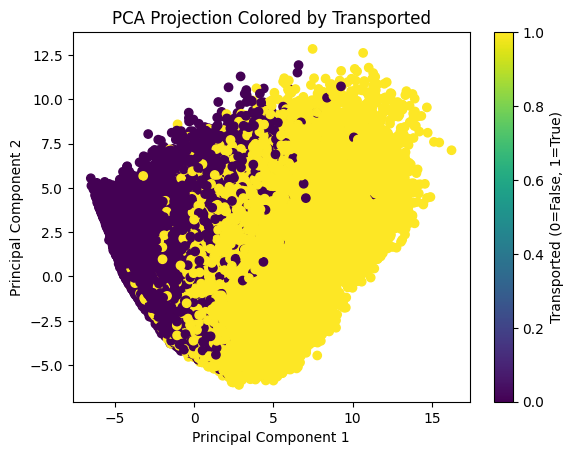

Explained variance ratio: [0.20633717 0.08063212]
Total variance captured: 0.28696928974641345


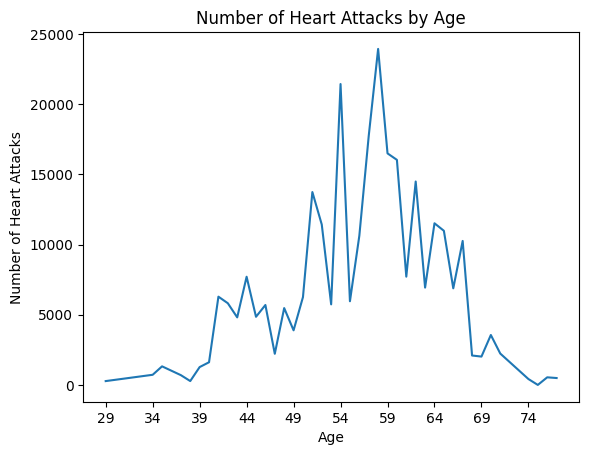

In [7]:
#see if PCA can help, maybe some obvious islands or linear boundaries


#PCA
#now lets do some PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


y = train["Heart Disease"] # True → 1, False → 0
X = train.drop(columns=["Heart Disease"])

X = pd.get_dummies(X, drop_first=True)
#scale it
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.figure()

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y   # color by transported
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection Colored by Transported")
plt.colorbar(scatter, label="Transported (0=False, 1=True)")
plt.show()


print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

#seems to be a mix, so I think a tree based model would work well

#lets get counts for different regions of people getting heart attacks with age
age_heart_counts = (
    train.groupby("Age")["Heart Disease"]
    .sum()
)

import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(age_heart_counts.index, age_heart_counts.values)

plt.xlabel("Age")
plt.ylabel("Number of Heart Attacks")
plt.title("Number of Heart Attacks by Age")

plt.xticks(
    np.arange(
        age_heart_counts.index.min(),
        age_heart_counts.index.max() + 1,
        5
    )
)

plt.show()

#we can see spikes from 55-60 is high, 50-55 is medium and 60-65, low is everything else, lets bin this 



In [8]:
#split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


In [9]:
#run a baseline random forest model
#baseline random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

feat_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_importance.head(20))


Accuracy: 0.8835396825396825
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000

Thallium_win                   0.071145
normal_heart                   0.069281
Thallium                       0.069031
reversible_heart_defect        0.053603
Chest pain type                0.048667
Chest pain type_win            0.039404
Max HR_win                     0.036139
cp_none                        0.036081
hr_stress_ratio                0.035906
hr_stress_ratio_win            0.035646
Max HR                         0.035609
Number of vessels fluro        0.032130
Number of vessels fluro_win    0.031774
id                             0.031234
id_win                         0.030880
Cholesterol                    0.025528
Chol

In [10]:
#explore thallium to see if we could simplify it for our model
train['Thallium'].unique()
#considering some googling we will add new categories based on these ints
train['normal_heart'] = (train['Thallium'] == 3).astype(int)
train['fixed_heart_defect'] = (train['Thallium'] == 6).astype(int)
train['reversible_heart_defect'] = (train['Thallium'] == 7).astype(int)

#lets try to bin some age categories
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,...,EKG results_win,Max HR_win,Exercise angina_win,ST depression_win,Slope of ST_win,Number of vessels fluro_win,Thallium_win,stress_ST_interaction_win,st_squared_win,hr_stress_ratio_win
0,0,58,1,4,152,239,0,0,158,1,...,0,158,1,3.6,2,2,7,3.4,12.96,2.677966
1,1,52,1,1,125,325,0,2,171,0,...,2,171,0,0.0,1,0,3,0.0,0.00,3.226415
2,2,56,0,2,160,188,0,2,151,0,...,2,151,0,0.0,1,0,3,0.0,0.00,2.649123
3,3,44,0,3,134,229,0,2,150,0,...,2,150,0,1.0,2,0,3,0.0,1.00,3.333333
4,4,58,1,4,140,234,0,2,125,1,...,2,125,1,3.6,2,3,3,3.4,12.96,2.118644


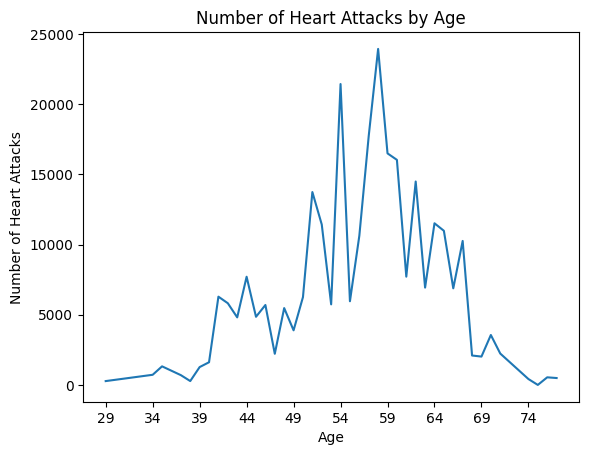

In [11]:
#lets get counts for different regions of people getting heart attacks with age
age_heart_counts = (
    train.groupby("Age")["Heart Disease"]
    .sum()
)

import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(age_heart_counts.index, age_heart_counts.values)

plt.xlabel("Age")
plt.ylabel("Number of Heart Attacks")
plt.title("Number of Heart Attacks by Age")

plt.xticks(
    np.arange(
        age_heart_counts.index.min(),
        age_heart_counts.index.max() + 1,
        5
    )
)

plt.show()

#we can see spikes from 55-60 is high, 50-55 is medium and 60-65, low is everything else, lets bin this 
bins = [0, 50, 55, 60, 65, 120]

labels = [
    "Low",
    "Medium",
    "High",
    "Medium",
    "Low"
]

train["age_risk_bin"] = pd.cut(
    train["Age"],
    bins=bins,
    labels=labels,
    right=False,
    ordered=False
)


In [12]:
#lets try to look at other things we can diagnose from 

In [13]:
#do XGboost
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
xgb1 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
    
)

xgb1.fit(X_train, y_train)

preds = xgb1.predict(X_test)
probs = xgb1.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, preds))

feat_importance = pd.Series(
    xgb1.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_importance.head(20))


Accuracy: 0.8895793650793651
ROC AUC: 0.955908497541937
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

normal_heart                   0.366616
Thallium                       0.235145
cp_none                        0.069784
reversible_heart_defect        0.056172
Chest pain type                0.052863
Slope of ST                    0.021573
ST depression_win              0.018816
Number of vessels fluro        0.017767
Exercise angina                0.016624
Exercise angina_win            0.016486
Slope of ST_win                0.015910
Sex_win                        0.011801
Number of vessels fluro_win    0.011620
st_depression_high             0.008889
Sex                            0.008590
ST depression    

In [14]:
# #to do randomized search grid with XGboost do the below
# from xgboost import XGBClassifier
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform, randint

# xgb_base = XGBClassifier(
#     random_state=42,
#     n_jobs=-1,
#     eval_metric="logloss",
#     reg_lambda = 1,
#     tree_method="hist",  # faster training
#     #eval_set=[(X_test, y_test)],
#     early_stopping_rounds=10,
#     verbose=True
# )

# param_dist = {
#     "max_depth": randint(3, 10),
#     "learning_rate": uniform(0.01, 0.2),
#     "n_estimators": randint(200, 800),
#     "subsample": uniform(0.7, 0.3),
#     "colsample_bytree": uniform(0.7, 0.3),
#     "reg_alpha": uniform(0, 2),
#     "reg_lambda": uniform(0.5, 5)
# }

# random_search = RandomizedSearchCV(
#     estimator=xgb_base,
#     param_distributions=param_dist,
#     n_iter=30,                 # 👈 number of models tested
#     scoring="roc_auc",
#     cv=5,
#     verbose=3,
#     n_jobs=-1,
#     random_state=42
# )

# random_search.fit(X_train, y_train, eval_set=[(X_test, y_test)])

# best_xgb = random_search.best_estimator_

# print("Best Params:")
# print(random_search.best_params_)

# print("Best CV Score:")
# print(random_search.best_score_)



In [15]:
# from sklearn.metrics import roc_curve
# import numpy as np

# y_prob = best_xgb.predict_proba(X_test)[:,1]

# fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# best_thresh = thresholds[np.argmax(tpr - fpr)]

# print(best_thresh)

# y_test_prob = best_xgb.predict_proba(X_test)[:, 1]
# y_test_pred = (y_test_prob >= best_thresh).astype(int)
# print("Test accuracy @ tuned threshold:", roc_auc_score(y_test, y_test_pred))


In [16]:
train.shape

(630000, 51)

In [17]:
X_train.shape

(504000, 51)

In [18]:
import xgboost as xgb

import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42,
    base_score=0.5   # ⭐ FORCE CLEAN FLOAT
)

model.fit(X_train, y_train)



,objective,'binary:logistic'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


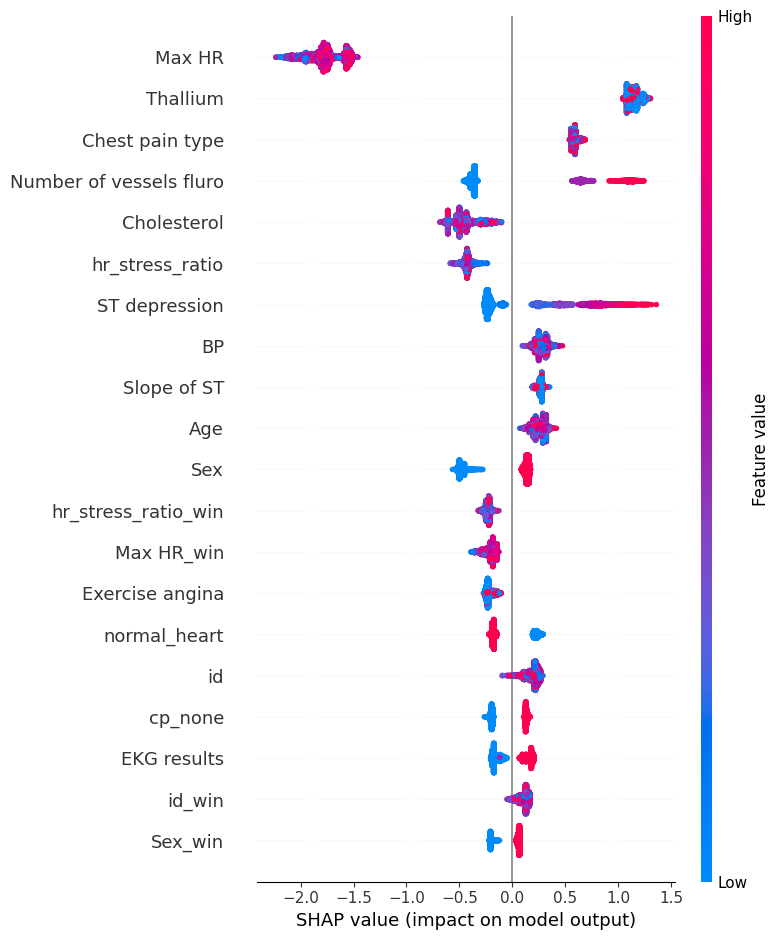

In [19]:
import shap
#train_cols = X_train.columns


explainer = shap.TreeExplainer(xgb1)

X_sample = X.sample(5000, random_state=42)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)


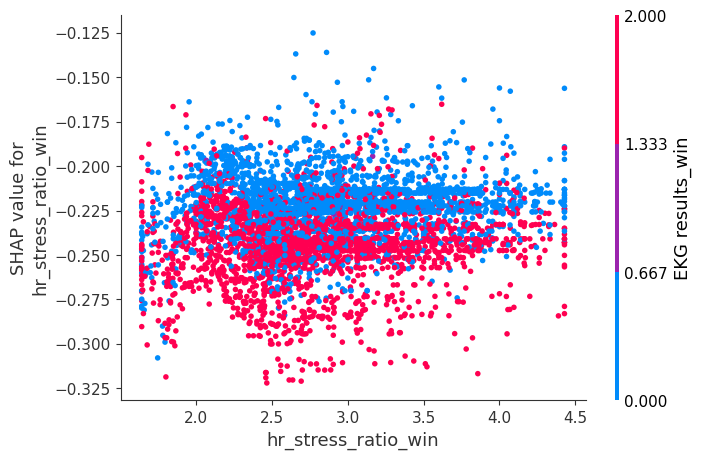

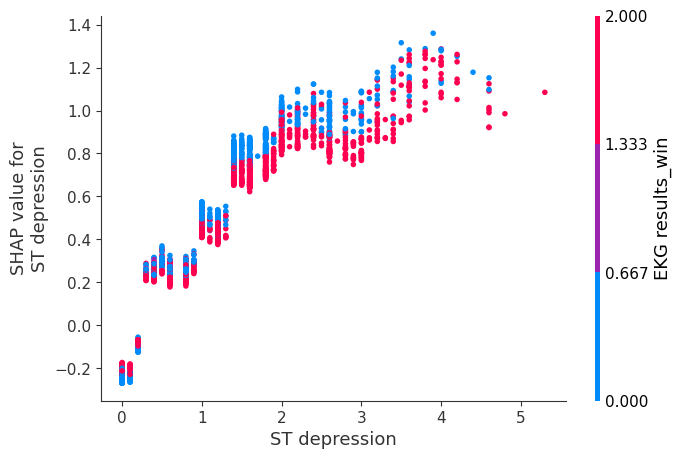

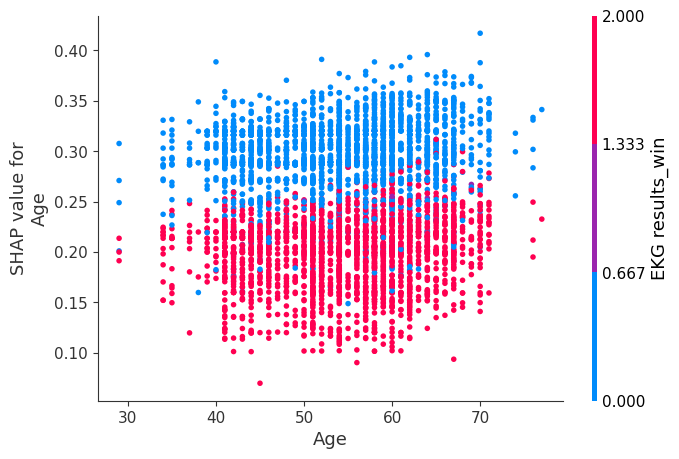

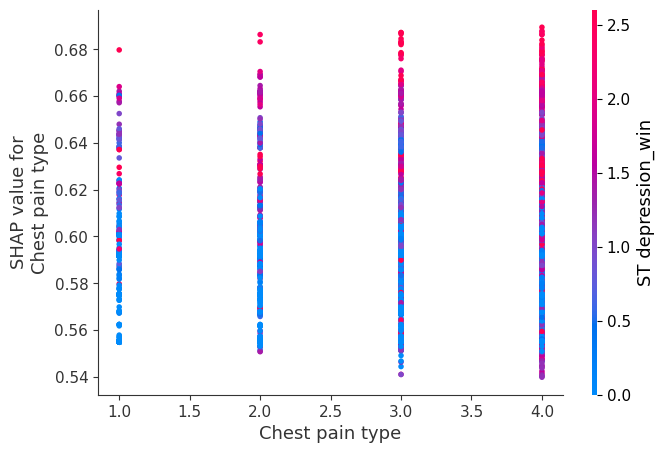

In [20]:
#make new cols based off of shap analysis
#do St depression, hr_stress_ratio_win, Age, chest pain 

#drop reversible_heart_defect, Slope of ST_win, 



#now lets examine hr_stress_ratio_win
shap.dependence_plot("hr_stress_ratio_win", shap_values, X_sample)

#now lets examine st depression
shap.dependence_plot("ST depression", shap_values, X_sample)
#now lets examine Age
shap.dependence_plot("Age", shap_values, X_sample)

#now lets examine chest pain
shap.dependence_plot("Chest pain type", shap_values, X_sample)


In [21]:
X_train["cp_thal_interaction"] = X_train["Chest pain type"] * X_train["Thallium"]

X_train["triple_ischemia_signal"] = (
    X_train["Chest pain type"] *
    X_train["Thallium"] *
    X_train["ST depression"]
)

X_test["cp_thal_interaction"] = X_test["Chest pain type"] * X_test["Thallium"]

X_test["triple_ischemia_signal"] = (
    X_test["Chest pain type"] *
    X_test["Thallium"] *
    X_test["ST depression"]
)



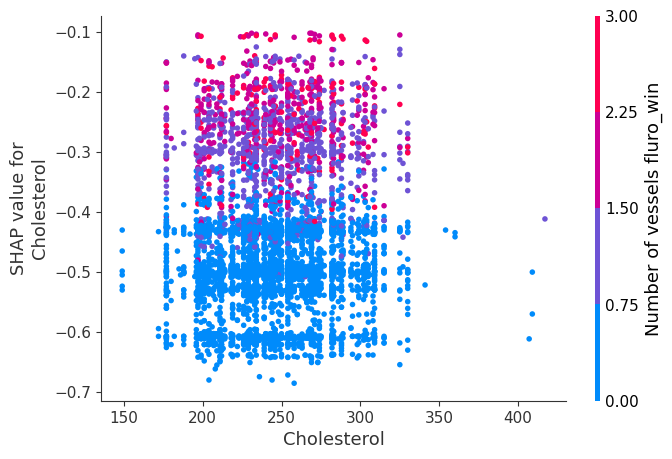

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


bin
(148.732, 162.4]   -0.491918
(162.4, 175.8]     -0.544615
(175.8, 189.2]     -0.432075
(189.2, 202.6]     -0.449824
(202.6, 216.0]     -0.451521
(216.0, 229.4]     -0.439787
(229.4, 242.8]     -0.438856
(242.8, 256.2]     -0.435996
(256.2, 269.6]     -0.428385
(269.6, 283.0]     -0.426381
(283.0, 296.4]     -0.428032
(296.4, 309.8]     -0.435559
(309.8, 323.2]     -0.464366
(323.2, 336.6]     -0.410974
(336.6, 350.0]     -0.521470
(350.0, 363.4]     -0.435259
(363.4, 376.8]           NaN
(376.8, 390.2]           NaN
(390.2, 403.6]           NaN
(403.6, 417.0]     -0.523151
Name: shap, dtype: float32

In [22]:
shap.dependence_plot("Cholesterol", shap_values, X_sample)

feat = "Cholesterol"
feat_idx = list(X_sample.columns).index(feat)

df_tmp = pd.DataFrame({
    "hr": X_sample[feat],
    "shap": shap_values[:, feat_idx]
})

df_tmp["bin"] = pd.cut(df_tmp["hr"], bins=20)

df_tmp.groupby("bin")["shap"].mean()


In [23]:
#if cholesterol over 300 then significant
HR_COL = "Cholesterol"   # change if your column name differs

for df in [X_train, X_test]:   # add X_test if you have it
    df.loc[:, "low_hr_flag"] = (df[HR_COL] < 110).astype("int8")
    df.loc[:, "high_hr_flag"] = (df[HR_COL] > 155).astype("int8")


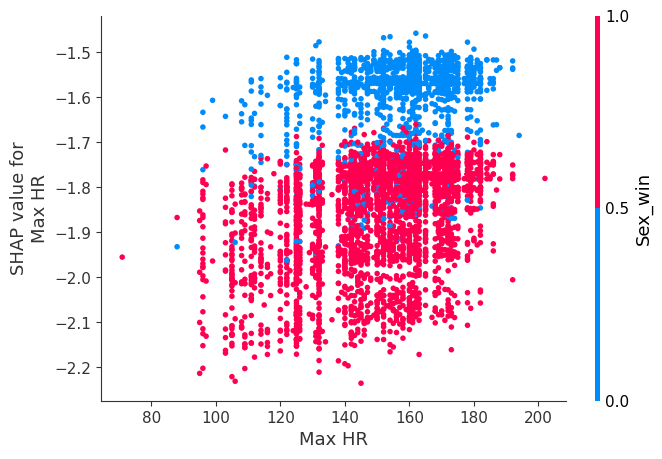

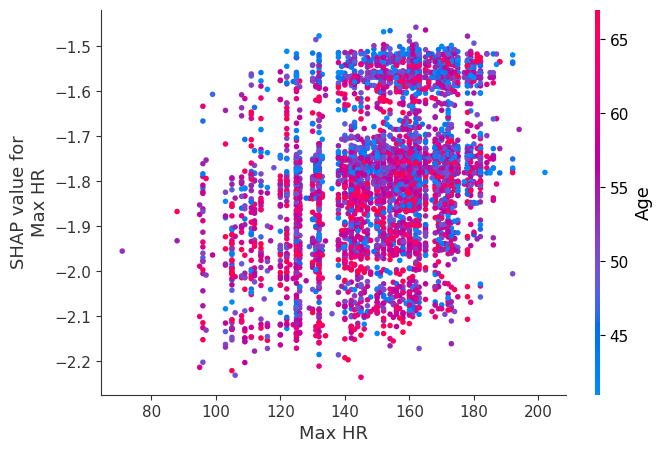

In [24]:
shap.dependence_plot("Max HR", shap_values, X_sample)

shap.dependence_plot(
    "Max HR",
    shap_values,
    X_sample,
    interaction_index="Age"
)



In [25]:
import numpy as np
import pandas as pd

feat = "Max HR"
feat_idx = list(X_sample.columns).index(feat)

df_tmp = pd.DataFrame({
    "hr": X_sample[feat],
    "shap": shap_values[:, feat_idx]
})

df_tmp["bin"] = pd.cut(df_tmp["hr"], bins=20)

df_tmp.groupby("bin")["shap"].mean()


The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


bin
(70.869, 77.55]   -1.954969
(77.55, 84.1]           NaN
(84.1, 90.65]     -1.899467
(90.65, 97.2]     -1.934064
(97.2, 103.75]    -1.932976
(103.75, 110.3]   -1.957543
(110.3, 116.85]   -1.888479
(116.85, 123.4]   -1.868470
(123.4, 129.95]   -1.884866
(129.95, 136.5]   -1.837260
(136.5, 143.05]   -1.809082
(143.05, 149.6]   -1.810540
(149.6, 156.15]   -1.778862
(156.15, 162.7]   -1.753280
(162.7, 169.25]   -1.737646
(169.25, 175.8]   -1.728683
(175.8, 182.35]   -1.708486
(182.35, 188.9]   -1.689682
(188.9, 195.45]   -1.706282
(195.45, 202.0]   -1.780136
Name: shap, dtype: float32

In [26]:
# =========
# Max HR SHAP-based flags
# =========

HR_COL = "Max HR"   # change if your column name differs

for df in [X_train, X_test]:   # add X_test if you have it
    df.loc[:, "low_hr_flag"] = (df[HR_COL] < 110).astype("int8")
    df.loc[:, "high_hr_flag"] = (df[HR_COL] > 155).astype("int8")


In [27]:
if "low_hr_flag" in X_train.columns:
    print("Column exists")
else:
    print("Column missing")


Column exists


In [28]:
#do XGboost
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
xgb1 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
    
)

xgb1.fit(X_train, y_train)

preds = xgb1.predict(X_test)
probs = xgb1.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, preds))

feat_importance = pd.Series(
    xgb1.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feat_importance.head(20))

print(feat_importance.head(20))


Accuracy: 0.8895396825396825
ROC AUC: 0.955885009224617
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

normal_heart                   0.333528
Thallium                       0.280695
cp_none                        0.094595
Chest pain type                0.056836
Thallium_win                   0.028033
Number of vessels fluro_win    0.017968
Slope of ST                    0.017717
Exercise angina_win            0.015603
Number of vessels fluro        0.015487
Exercise angina                0.014975
st_squared                     0.011933
Slope of ST_win                0.011049
Sex_win                        0.010559
reversible_heart_defect        0.009304
Sex                            0.008824
st_depression_hig

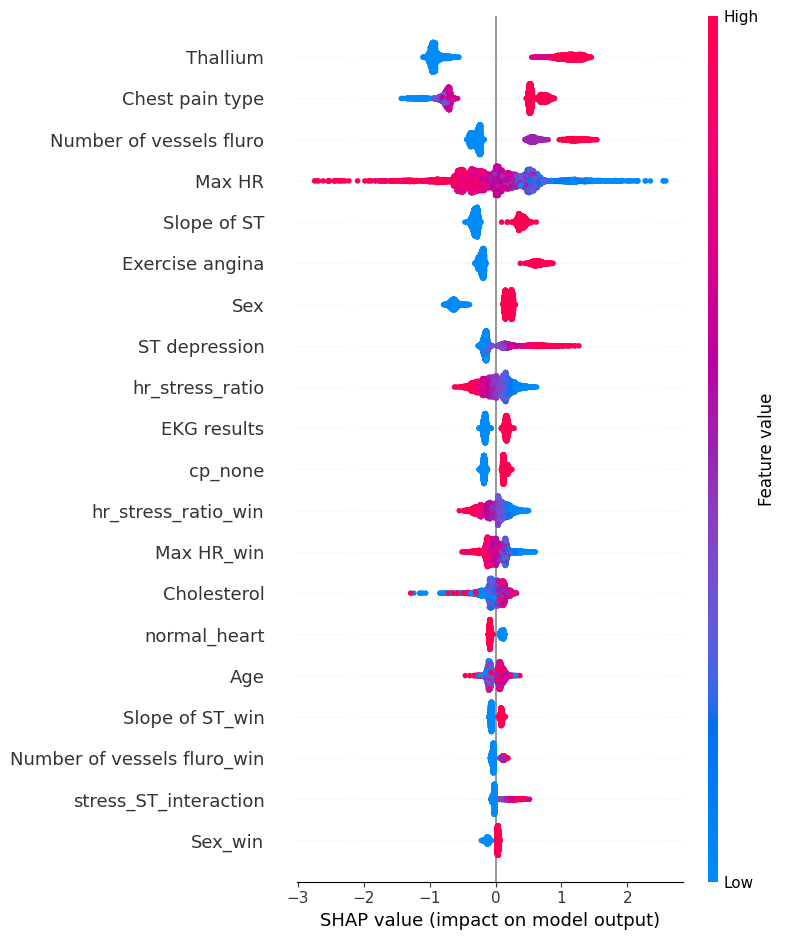

In [29]:
#now lets merge back into each other to be able to do SHAP again considering cp_thal_interaction proved to be useful from XGboost
X = pd.concat([X_train, X_test])
import shap
#train_cols = X_train.columns


explainer = shap.TreeExplainer(xgb1)

X_sample = X.sample(5000, random_state=42)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)


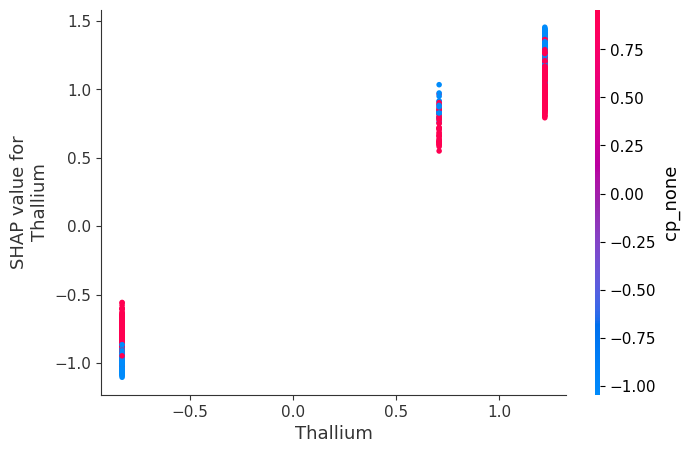

In [30]:
shap.dependence_plot("Thallium", shap_values, X_sample)

In [31]:
#from above we can see that if you have cp_none = red then they have no chest pain, blue dots then chest pain
# If Thallium == 3:
#     no chest pain → lowest risk
#     chest pain → low risk

# If Thallium == 6:
#     no chest pain → moderate risk
#     chest pain → moderate-high risk

# If Thallium == 7:
#     no chest pain → high risk
#     chest pain → very high risk

X_train["thal_cp_interaction"] = (
    X_train["Thallium"].astype(str) + "_" +
    X_train["cp_none"].astype(str)
)

X_test["thal_cp_interaction"] = (
    X_test["Thallium"].astype(str) + "_" +
    X_test["cp_none"].astype(str)
)
#then one hot encode these
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
).set_output(transform="pandas")

thal_train_df = ohe.fit_transform(X_train[["thal_cp_interaction"]])
thal_test_df = ohe.transform(X_test[["thal_cp_interaction"]])

#now lets drop thal_cp_interaction
X_train = X_train.drop(columns='thal_cp_interaction')
X_test = X_test.drop(columns='thal_cp_interaction')
#concat back
X_train = pd.concat([X_train, thal_train_df], axis=1)
X_test = pd.concat([X_test, thal_test_df], axis=1)

X = pd.concat([X_train, X_test])


In [32]:
#below is for getting rid of duplicates
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]
X = X.loc[:, ~X.columns.duplicated()]


In [33]:
# xgb1 = XGBClassifier(
#     n_estimators=500,
#     max_depth=6,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     n_jobs=-1,
#     eval_metric="logloss"
    
# )

# xgb1.fit(X_train, y_train)

# preds = xgb1.predict(X_test)
# probs = xgb1.predict_proba(X_test)[:, 1]

# print("Accuracy:", accuracy_score(y_test, preds))
# print("ROC AUC:", roc_auc_score(y_test, probs))
# print(classification_report(y_test, preds))

# feat_importance = pd.Series(
#     xgb1.feature_importances_,
#     index=X_train.columns
# ).sort_values(ascending=False)

# print(feat_importance.head(20))

# print(feat_importance.head(20))

In [34]:
# import shap

# explainer = shap.TreeExplainer(xgb1)

# X_sample = X_train.sample(3000, random_state=42)

# shap_interactions = explainer.shap_interaction_values(X_sample)

# import numpy as np
# import pandas as pd

# interaction_strength = np.abs(shap_interactions).mean(axis=0)

# interaction_df = pd.DataFrame(
#     interaction_strength,
#     index=X_sample.columns,
#     columns=X_sample.columns
# )

# pairs = []

# for i in range(len(interaction_df.columns)):
#     for j in range(i+1, len(interaction_df.columns)):
#         pairs.append((
#             interaction_df.index[i],
#             interaction_df.columns[j],
#             interaction_df.iloc[i, j]
#         ))

# top_pairs = (
#     pd.DataFrame(pairs, columns=["feat1","feat2","strength"])
#     .sort_values("strength", ascending=False)
# )

# print(top_pairs.head(20))

# for _, row in top_pairs.head(5).iterrows():
#     f1, f2 = row["feat1"], row["feat2"]

#     new_col = f"{f1}_x_{f2}"

#     X_train[new_col] = X_train[f1] * X_train[f2]
#     X_test[new_col] = X_test[f1] * X_test[f2]

# X_train[new_col+"_ratio"] = X_train[f1] / (X_train[f2] + 1e-6)

# X_train[new_col+"_flag"] = (
#     (X_train[f1] > X_train[f1].median()) &
#     (X_train[f2] > X_train[f2].median())
# ).astype(int)


In [35]:
# #only keep if ROC improves
# baseline = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

# # retrain after adding features

# new_score = roc_auc_score(y_test, new_model.predict_proba(X_test)[:,1])

# # print("Gain:", new_score - baseline)
# # Optuna chooses:
# # - which interactions to include
# # - which transforms to use


In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

baseline_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

baseline_model.fit(X_train, y_train)

baseline_roc = roc_auc_score(
    y_test,
    baseline_model.predict_proba(X_test)[:,1]
)

print("Baseline ROC:", baseline_roc)
#below is SHAP feature mining
import shap
import numpy as np
import pandas as pd

explainer = shap.TreeExplainer(baseline_model)

X_sample = X_train.sample(3000, random_state=42)

shap_interactions = explainer.shap_interaction_values(X_sample)

interaction_strength = np.abs(shap_interactions).mean(axis=0)

interaction_df = pd.DataFrame(
    interaction_strength,
    index=X_sample.columns,
    columns=X_sample.columns
)

pairs = []

for i in range(len(interaction_df.columns)):
    for j in range(i+1, len(interaction_df.columns)):
        pairs.append((
            interaction_df.index[i],
            interaction_df.columns[j],
            interaction_df.iloc[i, j]
        ))

top_pairs = (
    pd.DataFrame(pairs, columns=["feat1","feat2","strength"])
    .sort_values("strength", ascending=False)
)

print(top_pairs.head(10))

X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

for _, row in top_pairs.head(5).iterrows():

    f1, f2 = row["feat1"], row["feat2"]

    base = f"{f1}_x_{f2}"

    # Interaction multiply
    X_train_fe[base] = X_train_fe[f1] * X_train_fe[f2]
    X_test_fe[base]  = X_test_fe[f1] * X_test_fe[f2]

    # Ratio
    X_train_fe[base+"_ratio"] = X_train_fe[f1] / (X_train_fe[f2] + 1e-6)
    X_test_fe[base+"_ratio"]  = X_test_fe[f1] / (X_test_fe[f2] + 1e-6)

    # Flag
    X_train_fe[base+"_flag"] = (
        (X_train_fe[f1] > X_train_fe[f1].median()) &
        (X_train_fe[f2] > X_train_fe[f2].median())
    ).astype(int)

    X_test_fe[base+"_flag"] = (
        (X_test_fe[f1] > X_train_fe[f1].median()) &
        (X_test_fe[f2] > X_train_fe[f2].median())
    ).astype(int)
#below we are testing new model with new features to see if performance increased
new_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

new_model.fit(X_train_fe, y_train)

new_score = roc_auc_score(
    y_test,
    new_model.predict_proba(X_test_fe)[:,1]
)

print("New ROC:", new_score)
print("Gain:", new_score - baseline_roc)


Baseline ROC: 0.9559322701995612
                        feat1  \
1788      cp_thal_interaction   
186           Chest pain type   
187           Chest pain type   
171                       Sex   
654   Number of vessels fluro   
498                    Max HR   
696   Number of vessels fluro   
606               Slope of ST   
182           Chest pain type   
474                    Max HR   

                                                  feat2  strength  
1788  thal_cp_interaction_-0.8298483733146281_-1.046...  0.059271  
186                                            Thallium  0.040948  
187                                        normal_heart  0.020598  
171   thal_cp_interaction_-0.8298483733146281_-1.046...  0.019823  
654                                            Thallium  0.019303  
498   thal_cp_interaction_-0.8298483733146281_-1.046...  0.017808  
696   thal_cp_interaction_-0.8298483733146281_-1.046...  0.016763  
606                                            Thallium  0.

In [37]:
#to do randomized search grid with XGboost do the below

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)


from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

xgb_base = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    reg_lambda = 1,
    tree_method="hist",  # faster training
    scale_pos_weight=scale_pos_weight
    #eval_set=[(X_test, y_test)],
    #early_stopping_rounds=10,
    #verbose=True
)

param_dist = {
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.12),
    "n_estimators": randint(200, 800),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "reg_alpha": uniform(0, 2),
    "reg_lambda": uniform(0.5, 5),
    "scale_pos_weight": uniform(scale_pos_weight * 0.5, scale_pos_weight),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5),
    "max_delta_step": randint(0, 5),
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,                 # 👈 number of models tested
    scoring="roc_auc",
    cv=cv,
    verbose=3,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_fe, y_train)

best_xgb = random_search.best_estimator_

print("Best Params:")
print(random_search.best_params_)

print("Best CV Score:")
print(random_search.best_score_)

#do early stopping on the best XGboost best model

best_xgb = XGBClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist",
    early_stopping_rounds=20,
    #scale_pos_weight=scale_pos_weight
)

best_xgb.fit(
    X_train_fe,
    y_train,
    eval_set=[(X_test_fe, y_test)],
    verbose=True
)



scale_pos_weight: 1.230453658342295
Fitting 10 folds for each of 30 candidates, totalling 300 fits


One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]


Best Params:
{'colsample_bytree': 0.8123620356542087, 'gamma': 4.75357153204958, 'learning_rate': 0.0978392730173686, 'max_delta_step': 4, 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 321, 'reg_alpha': 0.3119890406724053, 'reg_lambda': 0.7904180608409973, 'scale_pos_weight': 1.6810164365087452, 'subsample': 0.8803345035229626}
Best CV Score:
nan
[0]	validation_0-logloss:0.65805
[1]	validation_0-logloss:0.60650
[2]	validation_0-logloss:0.56371
[3]	validation_0-logloss:0.52775
[4]	validation_0-logloss:0.49695
[5]	validation_0-logloss:0.47071
[6]	validation_0-logloss:0.44794
[7]	validation_0-logloss:0.42828
[8]	validation_0-logloss:0.41119
[9]	validation_0-logloss:0.39619
[10]	validation_0-logloss:0.38320
[11]	validation_0-logloss:0.37167
[12]	validation_0-logloss:0.36161
[13]	validation_0-logloss:0.35267
[14]	validation_0-logloss:0.34489
[15]	validation_0-logloss:0.33798
[16]	validation_0-logloss:0.33185
[17]	validation_0-logloss:0.32639
[18]	validation_0-logloss:0.32158
[19]	v

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8123620356542087
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'logloss'


In [38]:
best_xgb = XGBClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    tree_method="hist",
    early_stopping_rounds=20,
    #scale_pos_weight=scale_pos_weight
)

best_xgb.fit(
    X_train_fe,
    y_train,
    eval_set=[(X_test_fe, y_test)],
    verbose=True
)

[0]	validation_0-logloss:0.65805
[1]	validation_0-logloss:0.60650
[2]	validation_0-logloss:0.56371
[3]	validation_0-logloss:0.52775
[4]	validation_0-logloss:0.49695
[5]	validation_0-logloss:0.47071
[6]	validation_0-logloss:0.44794
[7]	validation_0-logloss:0.42828
[8]	validation_0-logloss:0.41119
[9]	validation_0-logloss:0.39619
[10]	validation_0-logloss:0.38320
[11]	validation_0-logloss:0.37167
[12]	validation_0-logloss:0.36161
[13]	validation_0-logloss:0.35267
[14]	validation_0-logloss:0.34489
[15]	validation_0-logloss:0.33798
[16]	validation_0-logloss:0.33185
[17]	validation_0-logloss:0.32639
[18]	validation_0-logloss:0.32158
[19]	validation_0-logloss:0.31730
[20]	validation_0-logloss:0.31349
[21]	validation_0-logloss:0.31013
[22]	validation_0-logloss:0.30712
[23]	validation_0-logloss:0.30446
[24]	validation_0-logloss:0.30207
[25]	validation_0-logloss:0.29994
[26]	validation_0-logloss:0.29804
[27]	validation_0-logloss:0.29632
[28]	validation_0-logloss:0.29484
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8123620356542087
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'logloss'


In [39]:
#Best Params:{'colsample_bytree': 0.8123620356542087, 'learning_rate': 0.20014286128198325, 'max_depth': 5, 'n_estimators': 271, 'reg_alpha': 1.1973169683940732, 'reg_lambda': 1.2800932022121825, 'subsample': 0.7467983561008608
from sklearn.metrics import roc_auc_score

# probability of positive class
y_proba = best_xgb.predict_proba(X_test_fe)[:, 1]

roc = roc_auc_score(y_test, y_proba)

print("Test ROC-AUC:", roc)


Test ROC-AUC: 0.9556935259575252


Best Cost Threshold
threshold          0.128191
cost           37986.000000
sensitivity        0.980192
specificity        0.614496
net_benefit        0.408190
tp             55372.000000
fp             26796.000000
fn              1119.000000
tn             42713.000000
Name: 24, dtype: float64

Best Net Benefit Threshold
threshold          0.010000
cost           63799.000000
sensitivity        0.999770
specificity        0.084018
net_benefit        0.443134
tp             56478.000000
fp             63669.000000
fn                13.000000
tn              5840.000000
Name: 0, dtype: float64


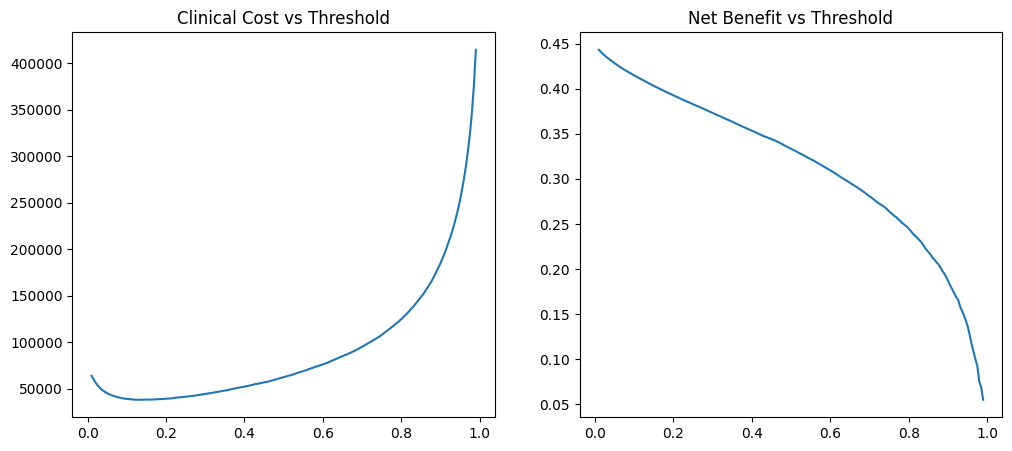

In [40]:
#threshold tuning
COST_FN = 10   # Missing disease very bad
COST_FP = 1    # False alarm less bad

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def medical_threshold_optimizer(
    y_true,
    y_proba,
    cost_fn=10,
    cost_fp=1
):
    thresholds = np.linspace(0.01, 0.99, 200)

    results = []

    N = len(y_true)

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        cost = fp * cost_fp + fn * cost_fn

        sensitivity = tp / (tp + fn) if (tp + fn) else 0
        specificity = tn / (tn + fp) if (tn + fp) else 0

        net_benefit = (
            tp/N
            - fp/N * (t / (1 - t))
        )

        results.append({
            "threshold": t,
            "cost": cost,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "net_benefit": net_benefit,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn
        })

    df = pd.DataFrame(results)

    best_cost = df.loc[df["cost"].idxmin()]
    best_nb = df.loc[df["net_benefit"].idxmax()]

    return df, best_cost, best_nb

y_proba = best_xgb.predict_proba(X_test_fe)[:, 1]

df_thresh, best_cost, best_nb = medical_threshold_optimizer(
    y_test,
    y_proba,
    cost_fn=10,
    cost_fp=1
)

print("Best Cost Threshold")
print(best_cost)

print("\nBest Net Benefit Threshold")
print(best_nb)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(df_thresh["threshold"], df_thresh["cost"])
plt.title("Clinical Cost vs Threshold")

plt.subplot(1,2,2)
plt.plot(df_thresh["threshold"], df_thresh["net_benefit"])
plt.title("Net Benefit vs Threshold")

plt.show()


In [41]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_train_fe)


In [42]:
# %pip install umap-learn


In [43]:
# import numpy as np
# import pandas as pd

# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
# from sklearn.mixture import GaussianMixture

# def build_hidden_phenotypes(
#     df: pd.DataFrame,
#     numeric_cols=None,
#     categorical_cols=None,
#     n_clusters_kmeans: int = 8,
#     n_clusters_gmm: int = 8,
#     n_pca: int = 8,
#     random_state: int = 42,
#     return_models: bool = False
# ):
#     """
#     Returns:
#       df_out: original df + phenotype features:
#         - pca_0..pca_{n_pca-1}
#         - kmeans_cluster
#         - kmeans_dist_0..dist_{k-1}
#         - gmm_cluster
#         - gmm_prob_0..prob_{k-1}
#         - gmm_nll (negative log-likelihood per row)
#     """

#     df = df.copy()

#     # Auto-detect columns if not provided
#     if numeric_cols is None:
#         numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
#     if categorical_cols is None:
#         categorical_cols = [c for c in df.columns if c not in numeric_cols]

#     # Preprocess pipelines
#     num_pipe = Pipeline(steps=[
#         ("imputer", SimpleImputer(strategy="median")),
#         ("scaler", StandardScaler()),
#     ])

#     cat_pipe = Pipeline(steps=[
#         ("imputer", SimpleImputer(strategy="most_frequent")),
#         ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
#     ])

#     pre = ColumnTransformer(
#         transformers=[
#             ("num", num_pipe, numeric_cols),
#             ("cat", cat_pipe, categorical_cols),
#         ],
#         remainder="drop",
#         verbose_feature_names_out=False,
#     ).set_output(transform="pandas")

#     # Fit-transform features
#     X = pre.fit_transform(df)  # pandas output
#     X_np = X.to_numpy(dtype=float)

#     # Embeddings (PCA)
#     n_pca_eff = min(n_pca, X_np.shape[1])
#     pca = PCA(n_components=n_pca_eff, random_state=random_state)
#     X_pca = pca.fit_transform(X_np)

#     # Clustering on embeddings (often cleaner than raw)
#     kmeans = KMeans(n_clusters=n_clusters_kmeans, n_init="auto", random_state=random_state)
#     kmeans_cluster = kmeans.fit_predict(X_pca)

#     # Distances to each centroid (very useful meta-features)
#     kmeans_dists = kmeans.transform(X_pca)  # shape: (n, k)

#     # Soft clustering (GMM) on embeddings
#     gmm = GaussianMixture(
#         n_components=n_clusters_gmm,
#         covariance_type="full",
#         random_state=random_state,
#         n_init=2
#     )
#     gmm.fit(X_pca)
#     gmm_prob = gmm.predict_proba(X_pca)          # shape: (n, k)
#     gmm_cluster = gmm_prob.argmax(axis=1)
#     gmm_nll = -gmm.score_samples(X_pca)          # higher = more "atypical"

#     # Assemble output features
#     out = df.copy()

#     for j in range(X_pca.shape[1]):
#         out[f"pca_{j}"] = X_pca[:, j]

#     out["kmeans_cluster"] = kmeans_cluster
#     for j in range(kmeans_dists.shape[1]):
#         out[f"kmeans_dist_{j}"] = kmeans_dists[:, j]

#     out["gmm_cluster"] = gmm_cluster
#     for j in range(gmm_prob.shape[1]):
#         out[f"gmm_prob_{j}"] = gmm_prob[:, j]

#     out["gmm_nll"] = gmm_nll

#     if return_models:
#         models = {
#             "preprocessor": pre,
#             "pca": pca,
#             "kmeans": kmeans,
#             "gmm": gmm,
#             "numeric_cols": numeric_cols,
#             "categorical_cols": categorical_cols,
#         }
#         return out, models

#     return out

# df_feat, models = build_hidden_phenotypes(
#     df=train.drop(columns=["Heart Disease"]),  # or your feature df
#     n_clusters_kmeans=8,
#     n_clusters_gmm=8,
#     n_pca=10,
#     return_models=True
# )

# # Then add target back if you want
# df_feat["target"] = train["Heart Disease"].values

# X = df_feat.drop(columns=["target"])
# y = df_feat["target"].astype(int)

# # IMPORTANT: treat cluster labels as categorical
# # If you use XGBoost (sklearn wrapper), simplest is one-hot them:
# X = pd.get_dummies(X, columns=["kmeans_cluster", "gmm_cluster"], drop_first=False)

# # Train your model as usual
# # pip install umap-learn
# import umap

# def add_umap_embeddings(df_feat, models, n_umap=2, random_state=42):
#     pre = models["preprocessor"]
#     pca = models["pca"]

#     X = pre.transform(df_feat)
#     X_np = X.to_numpy(dtype=float)
#     X_pca = pca.transform(X_np)

#     reducer = umap.UMAP(
#         n_components=n_umap,
#         n_neighbors=25,
#         min_dist=0.1,
#         random_state=random_state
#     )
#     X_umap = reducer.fit_transform(X_pca)

#     out = df_feat.copy()
#     for j in range(n_umap):
#         out[f"umap_{j}"] = X_umap[:, j]
#     return out


In [44]:
# shap.dependence_plot("Thallium_win", shap_values, X_sample)
# shap.dependence_plot("normal_heart", shap_values, X_sample)

In [45]:
#doing XGboost and random forest ensemble
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

print("RF ROC:", roc_auc_score(y_test, rf_probs))
print("XGB ROC:", roc_auc_score(y_test, xgb_probs))

blend_probs = 0.4*rf_probs + 0.6*xgb_probs

print("Blend ROC:", roc_auc_score(y_test, blend_probs))

best_score = 0
best_w = 0

for w in np.linspace(0,1,50):
    
    blended = w*rf_probs + (1-w)*xgb_probs
    
    score = roc_auc_score(y_test, blended)
    
    if score > best_score:
        best_score = score
        best_w = w

print("Best RF weight:", best_w)
print("Best ROC:", best_score)

stack_model = StackingClassifier(
    estimators=[
        ("rf", rf_model),
        ("xgb", xgb_model)
    ],
    final_estimator=LogisticRegression(),
    passthrough=False,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

stack_probs = stack_model.predict_proba(X_test)[:,1]

print("Stack ROC:", roc_auc_score(y_test, stack_probs))

results = pd.DataFrame({
    "Model":[
        "RandomForest",
        "XGBoost",
        "Blend",
        "Stack"
    ],
    "ROC":[
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs),
        roc_auc_score(y_test, blend_probs),
        roc_auc_score(y_test, stack_probs)
    ]
})

print(results.sort_values("ROC", ascending=False))

print("Prediction Correlation:")
print(np.corrcoef(rf_probs, xgb_probs))


RF ROC: 0.9532881060481936
XGB ROC: 0.9559322701995612
Blend ROC: 0.955430405996655
Best RF weight: 0.0
Best ROC: 0.9559322701995612
Stack ROC: 0.9556879531167604
          Model       ROC
1       XGBoost  0.955932
3         Stack  0.955688
2         Blend  0.955430
0  RandomForest  0.953288
Prediction Correlation:
[[1.         0.99299665]
 [0.99299665 1.        ]]


In [46]:
#

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

def build_model(input_dim):

    model = keras.Sequential([
        
        layers.Input(shape=(input_dim,)),
        
        layers.BatchNormalization(),
        
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )

    return model

model = build_model(X_train_scaled.shape[1])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=1024,   # Big dataset → big batch OK
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

nn_probs = model.predict(X_test_scaled).ravel()
nn_preds = (nn_probs > 0.5).astype(int)

print("NN ROC:", roc_auc_score(y_test, nn_probs))
print("NN ACC:", accuracy_score(y_test, nn_preds))

xgb_probs

print("NN vs XGB correlation:",
      np.corrcoef(nn_probs, xgb_probs)[0,1])



Class weights: {0: 0.9063541902696404, 1: 1.1152268291711476}
Epoch 1/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - auc: 0.9461 - loss: 0.2973 - val_auc: 0.9543 - val_loss: 0.2749
Epoch 2/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.9502 - loss: 0.2852 - val_auc: 0.9544 - val_loss: 0.2756
Epoch 3/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.9508 - loss: 0.2836 - val_auc: 0.9544 - val_loss: 0.2743
Epoch 4/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.9510 - loss: 0.2830 - val_auc: 0.9545 - val_loss: 0.2732
Epoch 5/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.9511 - loss: 0.2829 - val_auc: 0.9544 - val_loss: 0.2749
Epoch 6/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.9512 - loss: 0.2823 - val_auc: 0.9545 - val_loss: 0.2748
Epoch 7/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.9513 - loss: 0.2823 - val_auc: 0.9545 - val_loss: 0.2724
Epoch 8/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.9514 - loss: 0.2821 - val_auc: 0.9545 - val

In [47]:
#%pip install pytorch-tabnet
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_params=dict(lr=2e-2),
    seed=42
)

tabnet.fit(
    X_train_fe.values,
    y_train.values,
    eval_set=[(X_test_fe.values, y_test.values)],
    max_epochs=200,
    patience=20,
    batch_size=1024
)
train_embed = tabnet.network(
    tabnet.network.initial_bn(
        tabnet.network.embedding_generator(
            X_train_fe.values
        )
    )
)[0].detach().cpu().numpy()

for i in range(train_embed.shape[1]):
    X_train_fe[f"tabnet_emb_{i}"] = train_embed[:,i]


Device used : cpu


epoch 0  | loss: 0.3469  | val_0_auc: 0.94182 |  0:01:01s
epoch 1  | loss: 0.30446 | val_0_auc: 0.94806 |  0:02:03s
epoch 2  | loss: 0.29684 | val_0_auc: 0.95105 |  0:03:06s
epoch 3  | loss: 0.28669 | val_0_auc: 0.95245 |  0:04:08s
epoch 4  | loss: 0.28262 | val_0_auc: 0.95234 |  0:05:11s
epoch 5  | loss: 0.28126 | val_0_auc: 0.95285 |  0:06:14s
epoch 6  | loss: 0.28398 | val_0_auc: 0.95203 |  0:07:17s
epoch 7  | loss: 0.28358 | val_0_auc: 0.95196 |  0:08:21s
epoch 8  | loss: 0.28187 | val_0_auc: 0.95319 |  0:09:25s
epoch 9  | loss: 0.27904 | val_0_auc: 0.95302 |  0:10:28s
epoch 10 | loss: 0.28025 | val_0_auc: 0.9538  |  0:11:31s
epoch 11 | loss: 0.27817 | val_0_auc: 0.95399 |  0:12:34s
epoch 12 | loss: 0.279   | val_0_auc: 0.95348 |  0:13:38s
epoch 13 | loss: 0.27747 | val_0_auc: 0.95398 |  0:14:42s
epoch 14 | loss: 0.27705 | val_0_auc: 0.95397 |  0:15:44s
epoch 15 | loss: 0.27727 | val_0_auc: 0.95396 |  0:16:47s
epoch 16 | loss: 0.27683 | val_0_auc: 0.95407 |  0:17:51s
epoch 17 | los

Best weights from best epoch are automatically used!


AttributeError: 'TabNet' object has no attribute 'initial_bn'

In [ ]:
for i in range(train_embed.shape[1]):
    X_train_fe[f"tabnet_emb_{i}"] = train_embed[:,i]

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

seeds = [3, 7, 11, 42, 99]
probas = []

for s in seeds:
    m = XGBClassifier(
        **random_search.best_params_,
        random_state=s,
        n_jobs=-1,
        eval_metric="logloss",
        tree_method="hist",
        early_stopping_rounds=30
    )
    m.fit(X_train_fe, y_train, eval_set=[(X_test_fe, y_test)], verbose=False)
    probas.append(m.predict_proba(X_test_fe)[:, 1])

xgb_ens = np.mean(probas, axis=0)
print("XGB seed-ensemble ROC:", roc_auc_score(y_test, xgb_ens))

# pip install pytorch-tabnet
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(
    n_d=16, n_a=16, n_steps=5,
    gamma=1.5, lambda_sparse=1e-4,
    optimizer_params=dict(lr=2e-2),
    seed=42
)

tabnet.fit(
    X_train_fe.values, y_train.values,
    eval_set=[(X_test_fe.values, y_test.values)],
    max_epochs=200, patience=20, batch_size=1024, virtual_batch_size=128
)

tab_proba = tabnet.predict_proba(X_test_fe.values)[:, 1]
print("TabNet ROC:", roc_auc_score(y_test, tab_proba))

best = (-1, None)
for w in np.linspace(0, 1, 21):
    blended = w * xgb_ens + (1 - w) * tab_proba
    roc = roc_auc_score(y_test, blended)
    if roc > best[0]:
        best = (roc, w)

print("Best blended ROC:", best[0], "with weight w (XGB):", best[1])


In [ ]:
# %pip uninstall shap xgboost -y
# %pip install shap==0.44.1 xgboost==2.0.3
#%pip install shap==0.44.1